# South Summit 2026 - End-to-End ML Pipeline
## Titanic Survival Prediction

This notebook demonstrates a complete ML workflow on Databricks:
1. **Exploratory Data Analysis** — understand the dataset
2. **Data Preprocessing** — handle missing values, encode features
3. **Model Training** — compare Logistic Regression, Random Forest, and LightGBM
4. **Model Registration** — register the best model to Unity Catalog
5. **Model Deployment** — serve the model via a REST endpoint

In [0]:
%pip install lightgbm category_encoders --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Load Titanic dataset from Unity Catalog Volume
df = pd.read_csv("/Volumes/classic_stable_1ogj68/genaids/genaids/titanic.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
display(df.head(10))

Dataset shape: (891, 12)

Column types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,null,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,null,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,null,S
6,0,3,"Moran, Mr. James",male,null,0,0,330877,8.4583,null,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.075,null,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,null,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,null,C


## 1. Exploratory Data Analysis

In [0]:
# Dataset statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDescriptive Statistics:")
display(df.describe())

# Feature type table
feature_types = pd.DataFrame({
    "Feature": ["PassengerId", "Survived", "Pclass", "Name", "Sex", "Age", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"],
    "Type": ["Numeric (ID)", "Binary Target", "Categorical Ordinal", "Text (drop)", "Categorical Nominal", "Numeric Float", "Numeric Integer", "Numeric Integer", "Text (drop)", "Numeric Float", "Categorical (high null)", "Categorical Nominal"]
})
print("\nFeature Types:")
display(feature_types)

DATASET OVERVIEW

Shape: 891 rows x 12 columns

Descriptive Statistics:


PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
891.0,891.0,891.0,714.0,891.0,891.0,891.0
446.0,0.3838383838383838,2.308641975308642,29.69911764705882,0.5230078563411896,0.38159371492704824,32.204207968574636
257.3538420152301,0.4865924542648575,0.836071240977049,14.526497332334042,1.1027434322934317,0.8060572211299483,49.6934285971809
1.0,0.0,1.0,0.42,0.0,0.0,0.0
223.5,0.0,2.0,20.125,0.0,0.0,7.9104
446.0,0.0,3.0,28.0,0.0,0.0,14.4542
668.5,1.0,3.0,38.0,1.0,0.0,31.0
891.0,1.0,3.0,80.0,8.0,6.0,512.3292



Feature Types:


Feature,Type
PassengerId,Numeric (ID)
Survived,Binary Target
Pclass,Categorical Ordinal
Name,Text (drop)
Sex,Categorical Nominal
Age,Numeric Float
SibSp,Numeric Integer
Parch,Numeric Integer
Ticket,Text (drop)
Fare,Numeric Float


/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314253-1610870200:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314253-1610870200:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died (0)', 'Survived (1)'])


Survival rate: 38.4% survived, 61.6% died


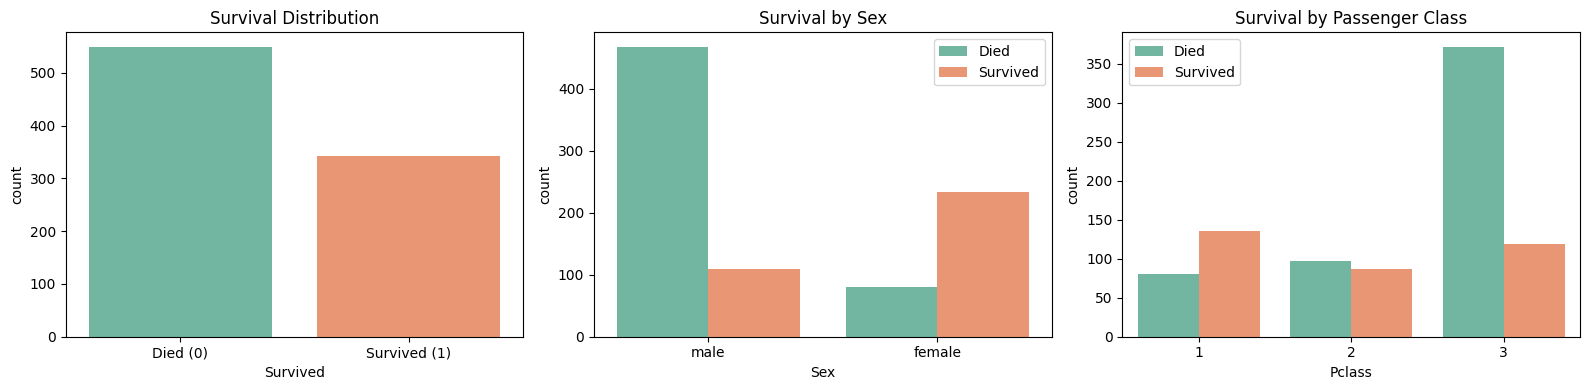

In [0]:
# Target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Survival counts
sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'])

survival_pct = df['Survived'].value_counts(normalize=True)
print(f"Survival rate: {survival_pct[1]:.1%} survived, {survival_pct[0]:.1%} died")

# Survival by Sex
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival by Sex')
axes[1].legend(['Died', 'Survived'])

# Survival by Pclass
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[2], palette='Set2')
axes[2].set_title('Survival by Passenger Class')
axes[2].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

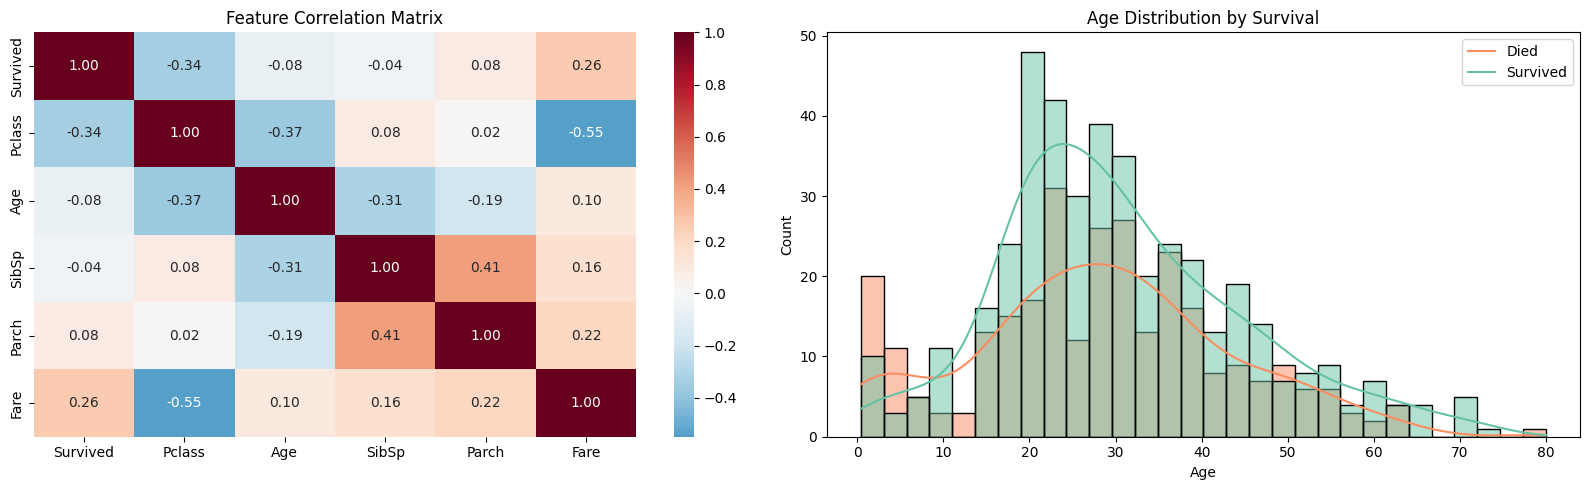

In [0]:
# Correlogram of numeric features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[0], fmt='.2f')
axes[0].set_title('Feature Correlation Matrix')

# Age distribution by survival
sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=axes[1], palette='Set2', bins=30)
axes[1].set_title('Age Distribution by Survival')
axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314255-1914377827:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[0], palette='Set2')
/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314255-1914377827:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314255-1914377827:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=embarked_survival, x='Embarked', y='Survived', ax=axes[1], palette='Set2')


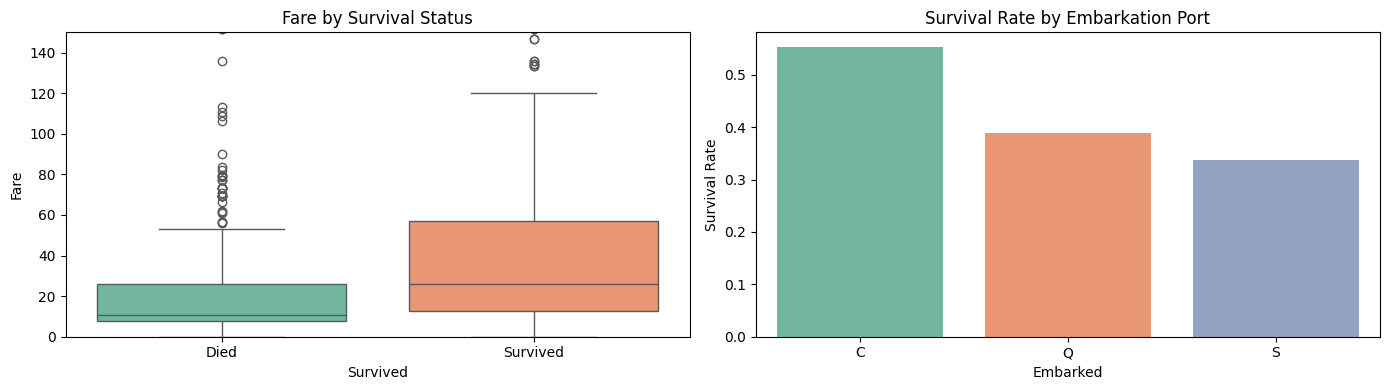

In [0]:
# Fare distribution and Embarked analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fare by survival (log scale for better viz)
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[0], palette='Set2')
axes[0].set_title('Fare by Survival Status')
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_ylim(0, 150)

# Survival rate by Embarked
embarked_survival = df.groupby('Embarked')['Survived'].mean().reset_index()
sns.barplot(data=embarked_survival, x='Embarked', y='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Embarkation Port')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Select features
features_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

# Prepare data
X = df[features_to_use].copy()
y = df[target].copy()

# Fill missing Embarked with mode
X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)

# Encode categorical features
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True)

# Split data (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# Impute Age and scale numeric features
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed feature shape: {X_train_processed.shape}")

Training set: 712 samples
Test set: 179 samples

Class distribution in training set:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Processed feature shape: (712, 8)


/home/spark-66483f98-4823-457c-ab00-89/.ipykernel/3379/command-6823171366314262-3316946793:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)


## 3. Model Training & Comparison
Training three algorithms:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — ensemble of decision trees
- **LightGBM** — gradient boosted trees (state-of-the-art)

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix, RocCurveDisplay
)

# Set MLflow experiment
mlflow.set_experiment("/Users/caio.moreno@databricks.com/south-summit-2026/titanic-survival")

# Define models to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, class_weight='balanced', verbose=-1)
}

results = {}

for name, model in models.items():
    with mlflow.start_run(run_name=name) as run:
        # Train
        model.fit(X_train_processed, y_train)
        
        # Predict
        y_pred = model.predict(X_test_processed)
        y_proba = model.predict_proba(X_test_processed)[:, 1]
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        # Log parameters and metrics
        mlflow.log_params(model.get_params())
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", auc)
        
        # Log model with signature
        signature = infer_signature(X_train_processed, y_pred)
        mlflow.sklearn.log_model(model, "model", signature=signature, input_example=X_train_processed[:5])
        
        results[name] = {"accuracy": acc, "f1_score": f1, "roc_auc": auc, "run_id": run.info.run_id}
        print(f"\n{name}: Accuracy={acc:.4f} | F1={f1:.4f} | ROC-AUC={auc:.4f}")

print("\n" + "=" * 60)
print("All models trained and logged to MLflow!")

2026/06/04 07:46:09 INFO mlflow.tracking.fluent: Experiment with name '/Users/caio.moreno@databricks.com/south-summit-2026/titanic-survival' does not exist. Creating a new experiment.
2026/06/04 07:46:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405606150133314.14.azuredatabricks.net/ml/experiments/507237341678235/models/m-dccef540ae3844b5989a413d70fab0ab?o=7405606150133314



Logistic Regression: Accuracy=0.8045 | F1=0.7552 | ROC-AUC=0.8465


2026/06/04 07:46:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405606150133314.14.azuredatabricks.net/ml/experiments/507237341678235/models/m-3f6a578fff834de496f53fef0d90f9cb?o=7405606150133314



Random Forest: Accuracy=0.8045 | F1=0.7407 | ROC-AUC=0.8447


/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/06/04 07:46:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405606150133314.14.azuredatabricks.net/ml/experiments/507237341678235/models/m-4f293ce7138d4a60ba009f3645c75395?o=7405606150133314
/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM: Accuracy=0.7821 | F1=0.7194 | ROC-AUC=0.8067

All models trained and logged to MLflow!


Model Comparison (sorted by ROC-AUC):


accuracy,f1_score,roc_auc
0.8044692737430168,0.7552447552447552,0.8465085638998683
0.8044692737430168,0.7407407407407407,0.8446640316205534
0.7821229050279329,0.7194244604316546,0.8066534914361001


/databricks/python/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


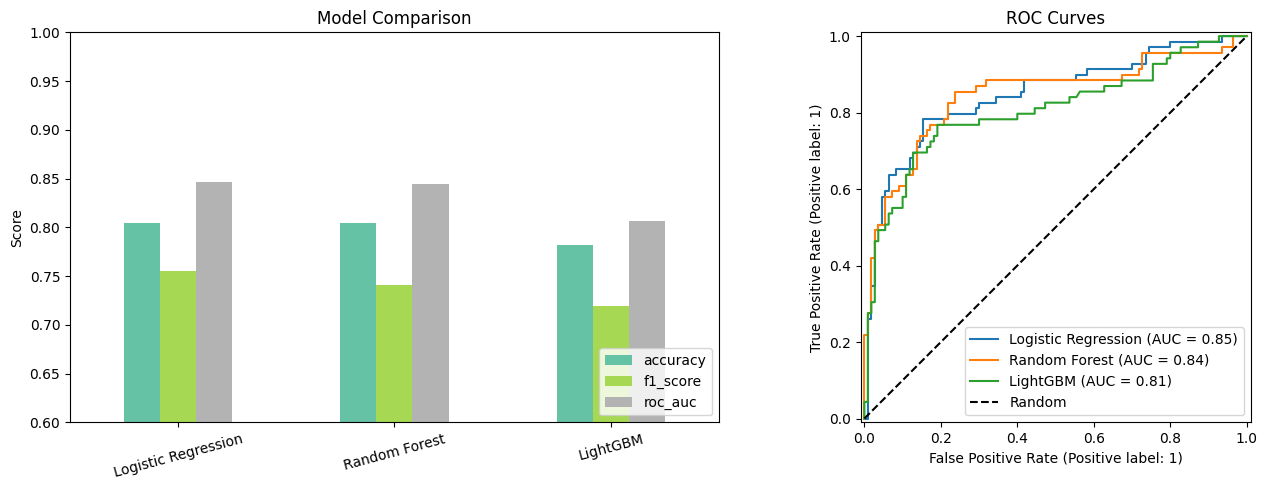


🏆 Best model: Logistic Regression (ROC-AUC: 0.8465)


In [0]:
# Model comparison table
results_df = pd.DataFrame(results).T
results_df = results_df.drop(columns=['run_id']).astype(float)
results_df = results_df.sort_values('roc_auc', ascending=False)
print("Model Comparison (sorted by ROC-AUC):")
display(results_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison bar chart
results_df[['accuracy', 'f1_score', 'roc_auc']].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Model Comparison')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.6, 1.0)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=15)

# ROC Curves
for name, model in models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])
axes[1].set_title('ROC Curves')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = results_df.index[0]
print(f"\n\U0001f3c6 Best model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f})")

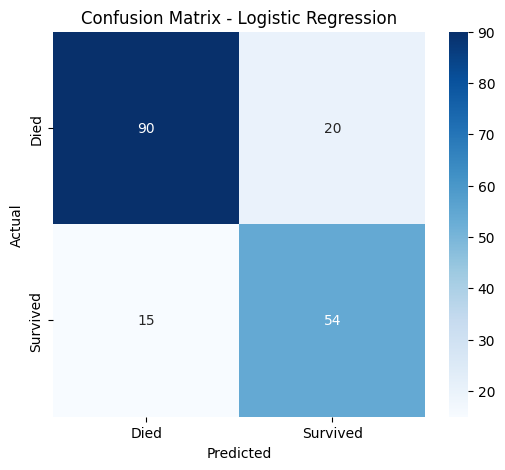


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

        Died       0.86      0.82      0.84       110
    Survived       0.73      0.78      0.76        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179



In [0]:
# Confusion matrix for best model
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_processed)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.show()

print(f"\nClassification Report - {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Died', 'Survived']))

## 4. Register Best Model to Unity Catalog

In [0]:
import mlflow
from mlflow import MlflowClient

# Set Unity Catalog as the model registry
mlflow.set_registry_uri("databricks-uc")

# Register the best model
catalog = "classic_stable_1ogj68"
schema = "genaids"
model_name = f"{catalog}.{schema}.titanic_survival_model"

# Get the best run ID
best_run_id = results[best_model_name]["run_id"]
model_uri = f"runs:/{best_run_id}/model"

# Register model
registered_model = mlflow.register_model(model_uri=model_uri, name=model_name)
print(f"\n\u2705 Model registered: {model_name}")
print(f"   Version: {registered_model.version}")

# Set alias 'champion'
client = MlflowClient()
client.set_registered_model_alias(model_name, "champion", registered_model.version)
print(f"   Alias 'champion' set to version {registered_model.version}")

Successfully registered model 'classic_stable_1ogj68.genaids.titanic_survival_model'.
2026/06/04 07:50:08 WARNING mlflow.tracking._model_registry.fluent: Run with id f628ac76ffa940caa9493dd0286823cd has no artifacts at artifact path 'model', registering model based on models:/m-dccef540ae3844b5989a413d70fab0ab instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '1' of model 'classic_stable_1ogj68.genaids.titanic_survival_model': https://adb-7405606150133314.14.azuredatabricks.net/explore/data/models/classic_stable_1ogj68/genaids/titanic_survival_model/version/1?o=7405606150133314



✅ Model registered: classic_stable_1ogj68.genaids.titanic_survival_model
   Version: 1
   Alias 'champion' set to version 1


## 5. Deploy Model to Serving Endpoint

In [0]:
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.serving import EndpointCoreConfigInput, ServedEntityInput
import time

w = WorkspaceClient()

endpoint_name = "titanic-survival-endpoint"

# Create or update the serving endpoint
try:
    endpoint = w.serving_endpoints.create(
        name=endpoint_name,
        config=EndpointCoreConfigInput(
            served_entities=[
                ServedEntityInput(
                    entity_name=model_name,
                    entity_version=registered_model.version,
                    scale_to_zero_enabled=True,
                    workload_size="Small",
                )
            ]
        ),
    )
    print(f"\u2705 Endpoint '{endpoint_name}' created!")
    print(f"   Model: {model_name} v{registered_model.version}")
    print(f"   Status: Provisioning (may take 5-10 minutes)")
except Exception as e:
    if "already exists" in str(e).lower():
        # Update existing endpoint
        w.serving_endpoints.update_config(
            name=endpoint_name,
            served_entities=[
                ServedEntityInput(
                    entity_name=model_name,
                    entity_version=registered_model.version,
                    scale_to_zero_enabled=True,
                    workload_size="Small",
                )
            ],
        )
        print(f"\u2705 Endpoint '{endpoint_name}' updated with new model version!")
    else:
        raise e

print(f"\n\U0001f517 Endpoint URL: /serving-endpoints/{endpoint_name}/invocations")

✅ Endpoint 'titanic-survival-endpoint' created!
   Model: classic_stable_1ogj68.genaids.titanic_survival_model v1
   Status: Provisioning (may take 5-10 minutes)

🔗 Endpoint URL: /serving-endpoints/titanic-survival-endpoint/invocations


In [0]:
# Test the endpoint with sample data (wait for it to be ready)
import json

# Sample passenger data for inference
sample_data = {
    "dataframe_records": [
        {"Pclass": 1, "Sex": 1, "Age": 29.0, "SibSp": 0, "Parch": 0, "Fare": 100.0, "Embarked_Q": 0, "Embarked_S": 0},
        {"Pclass": 3, "Sex": 0, "Age": 35.0, "SibSp": 1, "Parch": 2, "Fare": 15.0, "Embarked_Q": 0, "Embarked_S": 1},
    ]
}

print("Sample request payload:")
print(json.dumps(sample_data, indent=2))
print(f"\n\U0001f4a1 Once the endpoint is READY, test it with:")
print(f"   w.serving_endpoints.query(name='{endpoint_name}', dataframe_records=sample_data['dataframe_records'])")
print(f"\n   Or via REST API:")
print(f"   POST /serving-endpoints/{endpoint_name}/invocations")

Sample request payload:
{
  "dataframe_records": [
    {
      "Pclass": 1,
      "Sex": 1,
      "Age": 29.0,
      "SibSp": 0,
      "Parch": 0,
      "Fare": 100.0,
      "Embarked_Q": 0,
      "Embarked_S": 0
    },
    {
      "Pclass": 3,
      "Sex": 0,
      "Age": 35.0,
      "SibSp": 1,
      "Parch": 2,
      "Fare": 15.0,
      "Embarked_Q": 0,
      "Embarked_S": 1
    }
  ]
}

💡 Once the endpoint is READY, test it with:
   w.serving_endpoints.query(name='titanic-survival-endpoint', dataframe_records=sample_data['dataframe_records'])

   Or via REST API:
   POST /serving-endpoints/titanic-survival-endpoint/invocations
